=== Region Growing Segmentation ===


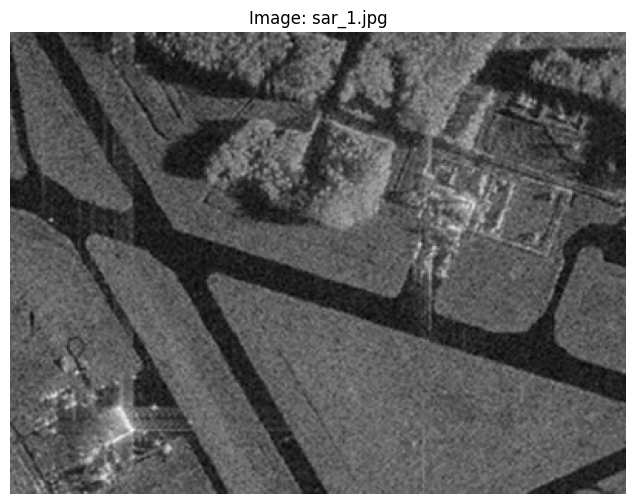

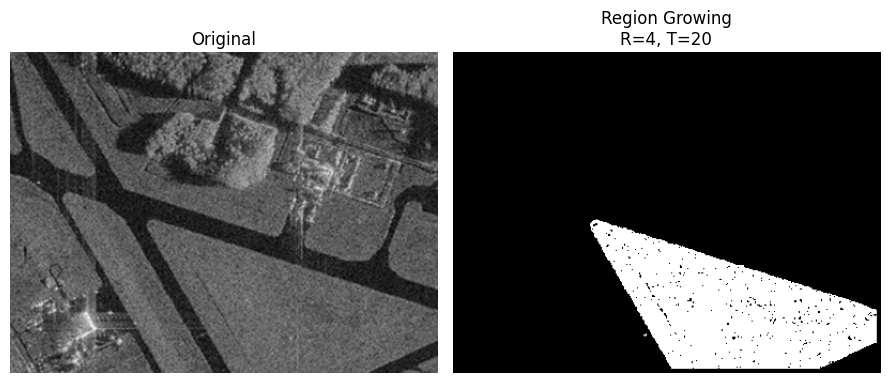

=== K-means Segmentation ===


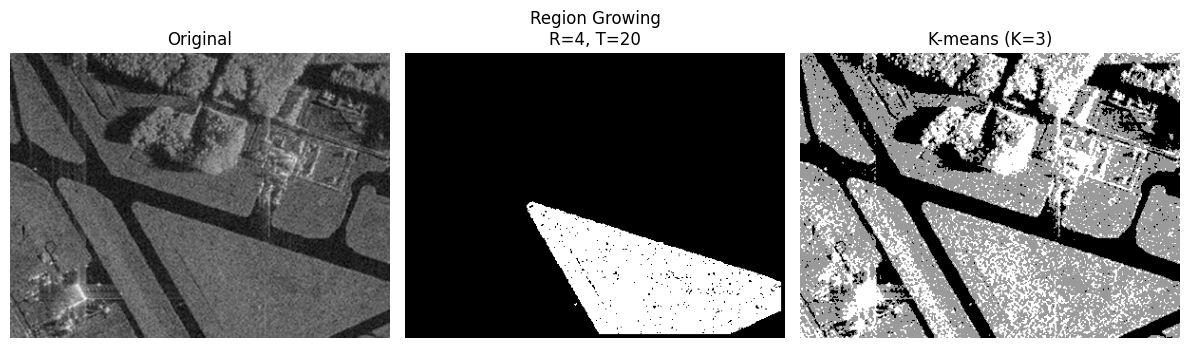

=== Watershed Palm Counting ===


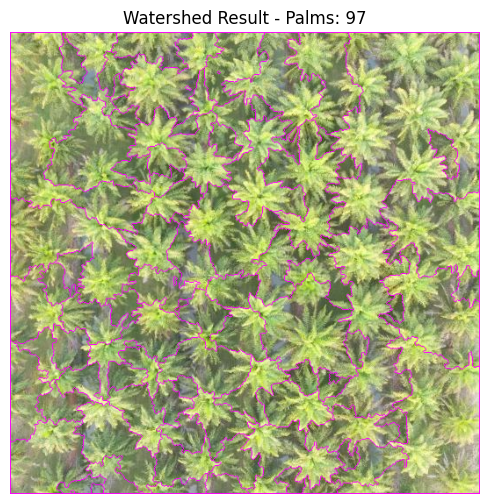

Detected palm count: 97


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Tuple, Callable


def load_and_show_image(image_path: str, grayscale: bool = True) -> np.ndarray:
    image = cv2.imread(image_path)
    if grayscale:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap="gray" if grayscale else None)
    plt.title(f"Image: {image_path}")
    plt.axis('off')
    plt.show()

    return image


def homogeneity_check(image: np.ndarray, mask: np.ndarray, point: Tuple[int, int], threshold: float) -> bool:
    region_pixels = image[mask > 0]

    if len(region_pixels) == 0:
        return False

    average_value = np.mean(region_pixels)
    point_value = image[point]

    return abs(average_value - point_value) <= threshold


def region_growing(
    image: np.ndarray,
    seed_point: Tuple[int, int],
    homogeneity_func: Callable,
    radius: int,
    threshold: float
) -> np.ndarray:

    height, width = image.shape
    mask = np.zeros_like(image, dtype=np.uint8)
    mask[seed_point] = 1

    while True:
        new_pixels_count = 0
        local_mask = np.zeros_like(image, dtype=np.uint8)

        # Проверяем только пиксели в допустимых границах
        for i in range(radius, height - radius):
            for j in range(radius, width - radius):
                if mask[i, j] == 0 and np.any(mask[i-radius:i+radius, j-radius:j+radius]):
                    if homogeneity_func(image, mask, (i, j), threshold):
                        local_mask[i, j] = 1
                        new_pixels_count += 1

        if new_pixels_count == 0:
            break

        mask = np.clip(mask + local_mask, 0, 1)

    return mask * 255


def apply_kmeans_segmentation(image: np.ndarray, k: int = 3) -> np.ndarray:
    # Подготовка данных для K-means
    pixel_data = np.float32(image.reshape((-1, 1)))

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixel_data, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Восстановление изображения
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()].reshape(image.shape)

    return segmented_image


def count_palms_with_watershed(image_path: str) -> Tuple[np.ndarray, int]:
    # Загрузка и предобработка
    palm = cv2.imread(image_path)
    palm_gray = cv2.cvtColor(palm, cv2.COLOR_BGR2GRAY)

    # Гауссово размытие и бинаризация
    palm_blurred = cv2.GaussianBlur(palm_gray, (11, 11), 0)
    _, binary = cv2.threshold(palm_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Distance transform для нахождения центров
    distance_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    _, sure_foreground = cv2.threshold(distance_transform, 0.58 * distance_transform.max(), 255, cv2.THRESH_BINARY)
    sure_foreground = sure_foreground.astype(np.uint8)

    # Watershed сегментация
    _, markers = cv2.connectedComponents(sure_foreground)
    markers = cv2.watershed(palm, markers.astype(np.int32))
    palm_count = len(np.unique(markers)) - 1  # -1 для фона

    # Визуализация результатов
    result_image = palm.copy()
    result_image[markers == -1] = [255, 0, 255]  # Границы регионов

    return result_image, palm_count


def display_images(images_dict: dict, figsize: Tuple[int, int] = (12, 5)):
    num_images = len(images_dict)
    fig, axes = plt.subplots(1, num_images, figsize=figsize)

    if num_images == 1:
        axes = [axes]

    for ax, (title, image) in zip(axes, images_dict.items()):
        ax.imshow(image, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def main():
    # 1. Region Growing сегментация
    print("=== Region Growing Segmentation ===")
    image_gray = load_and_show_image('sar_1.jpg')

    SEED_POINT = (250, 250)
    RADIUS = 4
    THRESHOLD = 20

    region_mask = region_growing(image_gray, SEED_POINT, homogeneity_check, RADIUS, THRESHOLD)

    images = {
        "Original": image_gray,
        f"Region Growing\nR={RADIUS}, T={THRESHOLD}": region_mask
    }
    display_images(images, figsize=(9, 5))

    # 2. K-means сегментация
    print("=== K-means Segmentation ===")
    kmeans_result = apply_kmeans_segmentation(image_gray, k=3)
    images["K-means (K=3)"] = kmeans_result
    display_images(images, figsize=(12, 5))

    # 3. Watershed для подсчета пальм
    print("=== Watershed Palm Counting ===")
    palm_result, palm_count = count_palms_with_watershed("palm_1.JPG")

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(palm_result, cv2.COLOR_BGR2RGB))
    plt.title(f"Watershed Result - Palms: {palm_count}")
    plt.axis('off')
    plt.show()

    print(f"Detected palm count: {palm_count}")


if __name__ == "__main__":
    main()